In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from lifelines import KaplanMeierFitter
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")
CATE_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_train.csv"
CATE_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_train.csv"
CATE_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_train.csv"
CATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_test.csv"
CATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_test.csv"
CATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_test.csv"
VI_H1_FP   = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP   = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP   = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"
PARQUET_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_train.parquet"
PARQUET_TEST_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_test_ver10.parquet"

h1 = pd.read_csv(CATE_H1_FP).rename(columns={"tau":"tau1"})
h2 = pd.read_csv(CATE_H2_FP).rename(columns={"tau":"tau2"})
h3 = pd.read_csv(CATE_H3_FP).rename(columns={"tau":"tau3"})
df = h1.merge(h2, on="PX_ID").merge(h3, on="PX_ID")

h1_test = pd.read_csv(CATE_H1_TEST_FP).rename(columns={"tau":"tau1"})
h2_test = pd.read_csv(CATE_H2_TEST_FP).rename(columns={"tau":"tau2"})
h3_test = pd.read_csv(CATE_H3_TEST_FP).rename(columns={"tau":"tau3"})
df_test = h1_test.merge(h2_test, on="PX_ID").merge(h3_test, on="PX_ID")

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

In [ ]:
def top_k_features(vi_csv, k=15):
    return vi_csv.sort_values("importance", ascending=False).head(k)["feature"].tolist()

top_feats = top_k_features(vi_h1)
print(f"Horizon 1 - top 15:", top_feats)
top_feats = top_k_features(vi_h2)
print(f"Horizon 2 - top 15:", top_feats)
top_feats = top_k_features(vi_h3)
print(f"Horizon 3 - top 15:", top_feats)

Horizon 1 - top 15: ['CAN_DIAB_TY_No', 'CAN_DIAB_TY_Unknown', 'CAN_DGN_Kidney Diabetic or metabolic nephropathy', 'CAN_MED_COND_MISSING', 'CAN_TOT_ALBUMIN', 'CAN_MED_COND_Not Hospitalized', 'MAX_CPRA', 'CAN_DRUG_TREAT_COPD', 'CAN_MAX_PCT_SCLER_LT10', 'CAN_DIAL_MISSING', 'CAN_AGE_AT_LISTING', 'CAN_MIN_FINAL_CREAT', 'CAN_MIN_PEAK_CREAT', 'CAN_RACE_White', 'CAN_DIAB_TY_Type II']
Horizon 2 - top 15: ['CAN_DGN_Kidney Diabetic or metabolic nephropathy', 'CAN_DIAB_TY_Unknown', 'CAN_DIAB_TY_No', 'CAN_TOT_ALBUMIN', 'CAN_MAX_PCT_SCLER_LT10', 'MAX_CPRA', 'CAN_MED_COND_Not Hospitalized', 'CAN_MED_COND_MISSING', 'CAN_RACE_White', 'CAN_AGE_AT_LISTING', 'CAN_DRUG_TREAT_COPD', 'CAN_MIN_FINAL_CREAT', 'CAN_MIN_PEAK_CREAT', 'CAN_DIAL_MISSING', 'CAN_FUNCTN_STAT_Independent with effort']
Horizon 3 - top 15: ['CAN_DGN_Kidney Diabetic or metabolic nephropathy', 'CAN_MAX_PCT_SCLER_LT10', 'CAN_DIAB_TY_No', 'CAN_TOT_ALBUMIN', 'MAX_CPRA', 'CAN_MED_COND_Not Hospitalized', 'CAN_RACE_White', 'CAN_DIAB_TY_Unknown', 

In [ ]:
rename_map = {
    "CAN_DIAB_TY_No": "No diabetes at listing",
    "CAN_DIAB_TY_Unknown": "Diabetes status unknown",
    "CAN_DGN_Kidney Diabetic or metabolic nephropathy": "Diagnosis: Diabetic/metabolic nephropathy",
    "CAN_MED_COND_MISSING": "Medical condition missing",
    "CAN_TOT_ALBUMIN": "Total serum albumin",
    "CAN_MED_COND_Not Hospitalized": "Not hospitalized at listing",
    "MAX_CPRA": "Calculated PRA",
    "CAN_DRUG_TREAT_COPD": "COPD treatment",
    "CAN_MAX_PCT_SCLER_LT10": "Max acceptable glomerular sclerosis",
    "CAN_DIAL_MISSING": "Dialysis info missing",
    "CAN_AGE_AT_LISTING": "Age at listing",
    "CAN_MIN_FINAL_CREAT": "Min acceptable donor Serum Creaininee - Peak",
    "CAN_MIN_PEAK_CREAT": "Min acceptable donor Serum Creaininee - Final",
    "CAN_RACE_White": "Race: White",
    "CAN_DIAB_TY_Type II": "Type II diabetes",
    "CAN_FUNCTN_STAT_Independent with effort": "Functional status: Independent with effort",
    "CAN_MALIG": "History of malignancy"
}

category_map = {
    "CAN_DIAB_TY_No": "Clinical History",
    "CAN_DIAB_TY_Unknown": "Clinical History",
    "CAN_DGN_Kidney Diabetic or metabolic nephropathy": "Comorbidity / Diagnosis",
    "CAN_MED_COND_MISSING": "Other",
    "CAN_TOT_ALBUMIN": "Lab Value",
    "CAN_MED_COND_Not Hospitalized": "Clinical History",
    "MAX_CPRA": "Lab Value",
    "CAN_DRUG_TREAT_COPD": "Comorbidity / Diagnosis",
    "CAN_MAX_PCT_SCLER_LT10": "Lab Value",
    "CAN_DIAL_MISSING": "Other",
    "CAN_AGE_AT_LISTING": "Demographic",
    "CAN_MIN_FINAL_CREAT": "Lab Value",
    "CAN_MIN_PEAK_CREAT": "Lab Value",
    "CAN_RACE_White": "Demographic",
    "CAN_DIAB_TY_Type II": "Clinical History",
    "CAN_FUNCTN_STAT_Independent with effort": "Functional Status",
    "CAN_MALIG": "Comorbidity / Diagnosis"
}

In [ ]:
k = 15
top_feats_h1 = set(top_k_features(vi_h1, k))
top_feats_h2 = set(top_k_features(vi_h2, k))
top_feats_h3 = set(top_k_features(vi_h3, k))

top_union = list(top_feats_h1 | top_feats_h2 | top_feats_h3)

In [ ]:
def normalize_vi(df):
    df = df.copy()
    df["importance_norm"] = df["importance"] / df["importance"].sum()
    return df

def filter_and_rename(df, feat_list, suffix):
    return df[df["feature"].isin(feat_list)][["feature", "importance_norm"]].rename(
        columns={"importance_norm": f"importance_{suffix}"}
    )

In [ ]:
vi_h1_norm = normalize_vi(vi_h1)
vi_h2_norm = normalize_vi(vi_h2)
vi_h3_norm = normalize_vi(vi_h3)

vi_h1_f = filter_and_rename(vi_h1_norm, top_union, "h1")
vi_h2_f = filter_and_rename(vi_h2_norm, top_union, "h2")
vi_h3_f = filter_and_rename(vi_h3_norm, top_union, "h3")

vi_merge = vi_h1_f.merge(vi_h2_f, on="feature", how="outer").merge(vi_h3_f, on="feature", how="outer").fillna(0)

vi_merge["importance_avg"] = vi_merge[["importance_h1", "importance_h2", "importance_h3"]].mean(axis=1)

vi_merge["feature_readable"] = vi_merge["feature"].map(rename_map).fillna(vi_merge["feature"])
vi_merge["category"] = vi_merge["feature"].map(category_map).fillna("Other")

vi_merge = vi_merge.sort_values("importance_avg", ascending=True)

In [ ]:
import numpy as np

In [ ]:
def normalize_vi(df):
    df = df.copy()
    s = df["importance"].sum()
    df["importance_norm"] = df["importance"] / (s if s != 0 else 1.0)
    return df

def top_k_features(df, k=10):
    return df.sort_values("importance", ascending=False).head(k)["feature"].tolist()

def pick(df, feats, suffix):
    return (df.loc[df["feature"].isin(feats), ["feature", "importance_norm"]]
              .rename(columns={"importance_norm": f"imp_{suffix}"}))

In [ ]:
vi_h1_n = normalize_vi(vi_h1)
vi_h2_n = normalize_vi(vi_h2)
vi_h3_n = normalize_vi(vi_h3)

k = 10
top_union = list(set(top_k_features(vi_h1, k)) |
                  set(top_k_features(vi_h2, k)) |
                  set(top_k_features(vi_h3, k)))

vi_m = (pick(vi_h1_n, top_union, "h1")
        .merge(pick(vi_h2_n, top_union, "h2"), on="feature", how="outer")
        .merge(pick(vi_h3_n, top_union, "h3"), on="feature", how="outer")
        .fillna(0.0))

vi_m["feature_readable"] = vi_m["feature"].map(rename_map).fillna(vi_m["feature"])
vi_m["category"] = vi_m["feature"].map(category_map).fillna("Other")

vi_m["imp_avg"] = vi_m[["imp_h1","imp_h2","imp_h3"]].mean(axis=1)
vi_m = vi_m.sort_values("imp_avg", ascending=True).reset_index(drop=True)


In [ ]:
import seaborn as sns


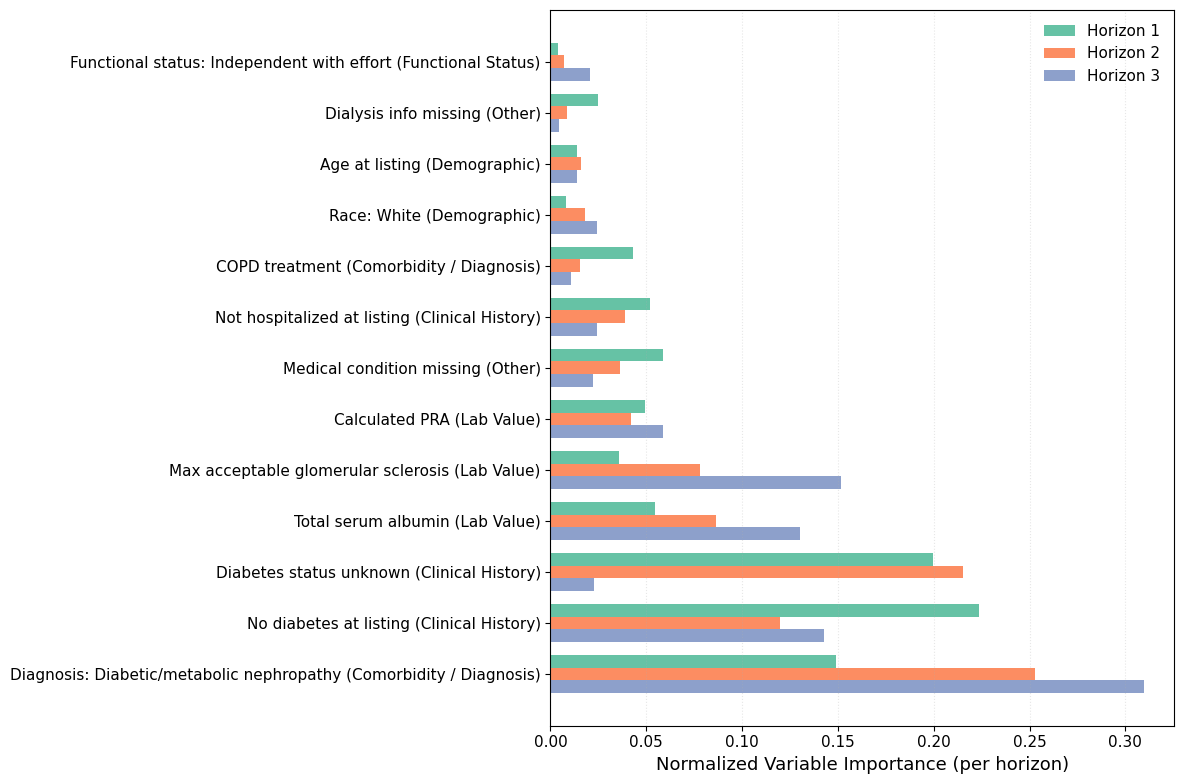

Saved: /Users/chanyoungwoo/Thesis/ATE_CATE/fig_variable_importance_k10.png
Saved: /Users/chanyoungwoo/Thesis/ATE_CATE/fig_variable_importance_k10.pdf


In [ ]:
colors = sns.color_palette("Set2", 3)  

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(vi_m))
bar_h = 0.25
offsets = [-bar_h, 0.0, bar_h]

labels = ["Horizon 1", "Horizon 2", "Horizon 3"]

ax.barh(y + offsets[0], vi_m["imp_h1"], height=bar_h, color=colors[0], label=labels[0])
ax.barh(y + offsets[1], vi_m["imp_h2"], height=bar_h, color=colors[1], label=labels[1])
ax.barh(y + offsets[2], vi_m["imp_h3"], height=bar_h, color=colors[2], label=labels[2])

yt = (vi_m["feature_readable"] + " (" + vi_m["category"] + ")").tolist()
ax.set_yticks(y)
ax.set_yticklabels(yt)
ax.invert_yaxis()

ax.set_xlabel("Normalized Variable Importance (per horizon)")

ax.legend(
    loc="upper right",
    frameon=False
)

ax.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

out_png = MAIN_DIR / "fig_variable_importance_k10.png"
out_pdf = MAIN_DIR / "fig_variable_importance_k10.pdf"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
print(f"Saved: {out_png}\nSaved: {out_pdf}")